# Architecture 3

In [1]:
import numpy as np
import pandas as pd
import torch
from types import SimpleNamespace


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))


import matplotlib.pyplot as plt
from deep_belief_betting.parameters import Parameters
from deep_belief_betting.market_sim import MarketSim
from deep_belief_betting.pretraining_path_generator import PretrainingPathGenerator
from deep_belief_betting.prediction_market_env import PredictionMarketEnv
from deep_belief_betting.smoke_train import SmokeTrainConfig, run_smoke_training

# Colab setup - if applicable 

# 1. Pulling Sim Data

In [3]:
def getSimData(seed):

    params = Parameters.from_yaml(PROJECT_ROOT / "configs" / "default.yaml")

    sim = MarketSim(params)
    state = sim.reset(seed=seed)

    rows = []
    rows.append(
        {
            "step": state.step,
            "time_to_resolution": state.time_to_resolution,
            "x": state.x,
            "q": state.q,
            "public_probability": state.public_probability,
            "latent_probability": state.latent_probability,
            "delta_q": state.delta_q,
            "informed_flow": state.informed_flow,
            "noise_flow": state.noise_flow,
            "terminal_outcome": state.terminal_outcome,
        }
    )

    done = False
    while not done:
        state, done = sim.step()
        rows.append(
            {
                "step": state.step,
                "time_to_resolution": state.time_to_resolution,
                "x": state.x,
                "q": state.q,
                "public_probability": state.public_probability,
                "latent_probability": state.latent_probability,
                "delta_q": state.delta_q,
                "informed_flow": state.informed_flow,
                "noise_flow": state.noise_flow,
                "terminal_outcome": state.terminal_outcome,
            }
        )

    return pd.DataFrame(rows)
    

In [4]:
def sim2model(n_examples, T_steps):
    
    sim_cols= []

    for i in range(T_steps+1):
        sim_cols.append("prob_"+str(i))
        sim_cols.append("feat_"+str(i))
        sim_cols.append("latent_"+str(i))

    df_sim = pd.DataFrame(columns= sim_cols)

    for n in range(n_examples):
        df_one_path= getSimData(seed=n)
        
        for i in range(T_steps+1):
            df_sim.loc[n,"prob_"+str(i)]= df_one_path.loc[i,"public_probability"]
            df_sim.loc[n,"feat_"+str(i)]= df_one_path.loc[i, "informed_flow"] + df_one_path.loc[i, "noise_flow"]
            df_sim.loc[n, "latent_"+str(i)]= df_one_path.loc[i,"latent_probability"]
            
            
    return df_sim

In [5]:
df= sim2model(100,60)
df.head()

,prob_0,feat_0,latent_0,prob_1,feat_1,latent_1,prob_2,feat_2,latent_2,prob_3,...,latent_57,prob_58,feat_58,latent_58,prob_59,feat_59,latent_59,prob_60,feat_60,latent_60
0,0.5,0.0,0.5,0.512497,1.0,0.546837,0.562177,4.0,0.574588,0.562177,...,0.825164,0.817574,-4.0,0.791101,0.817574,0.0,0.805253,0.817574,0.0,0.889092
1,0.5,0.0,0.5,0.46257,-3.0,0.544286,0.46257,0.0,0.5015,0.413382,...,0.942257,0.934011,3.0,0.959199,0.934011,0.0,0.962768,0.934011,0.0,0.961804
2,0.5,0.0,0.5,0.5,0.0,0.368279,0.53743,3.0,0.312742,0.562177,...,0.205355,0.365864,0.0,0.237172,0.331812,-3.0,0.229543,0.299433,-3.0,0.238492
3,0.5,0.0,0.5,0.512497,1.0,0.222656,0.5,-1.0,0.298343,0.46257,...,0.140801,0.2227,-1.0,0.126045,0.2227,0.0,0.138905,0.240489,2.0,0.136604
4,0.5,0.0,0.5,0.46257,-3.0,0.500119,0.425557,-3.0,0.63495,0.425557,...,0.804129,0.768525,0.0,0.820689,0.7773,1.0,0.832522,0.731059,-5.0,0.819156


In [6]:
df.to_csv("test_data.csv", index=False)

## 3. Load config and data

In [7]:
from model.data import load_config, PriceDataset

cfg= load_config("../configs/test_config.yaml")

print(f"T={cfg.T}, d_model={cfg.d_model}, n_layers={cfg.n_layers}, batch_size={cfg.batch_size}")

dataset = PriceDataset(csv_path=cfg.data_path, T=cfg.T)

print(f"dataset size: {len(dataset)}")

features_0, targets_0 = dataset[0]
print(f"example 0 features shape: {features_0.shape}")
print(f"example 0 targets shape:  {targets_0.shape}")

T=60, d_model=32, n_layers=2, batch_size=10
dataset size: 100
example 0 features shape: torch.Size([61, 2])
example 0 targets shape:  torch.Size([61])


## 4. Training

In [8]:
from model.train import train

model = train(cfg)
print("training complete")


[arch3] parameters: 0.02M  device=cpu  T+1=61  d_z=16  examples=100
epoch 1 step   20 | bce 0.6811 | mae 0.1756 | lr 9.05e-04
epoch 3 step   40 | bce 0.6641 | mae 0.1661 | lr 6.55e-04
epoch 5 step   60 | bce 0.6802 | mae 0.1297 | lr 3.45e-04
epoch 7 step   80 | bce 0.6503 | mae 0.1662 | lr 9.55e-05
epoch 9 step  100 | bce 0.6842 | mae 0.1525 | lr 0.00e+00
[arch3] saved checkpoint → /Users/assermaamoun/Documents/GeorgiaTech/GT-Courses/DL-CS7643/FinalProject/deep-belief-betting/runs/belief/test_belief_model.pt
training complete


## 5. Inspect predictions

In [9]:
model.eval()
features_ex, targets_ex = dataset[0]
L = cfg.T + 1
predictions = []

for i in range(L):
    x = features_ex[:i+1, :].unsqueeze(0)    
    with torch.no_grad():
        p_i, _, _ = model(x)
    predictions.append(p_i.item())

print("true latent:", [f"{v:.3f}" for v in targets_ex.tolist()])
print("predictions:", [f"{v:.3f}" for v in predictions])
print(f"MAE: {np.mean(np.abs(np.array(predictions) - targets_ex.numpy())):.4f}")

true latent: ['0.500', '0.547', '0.575', '0.553', '0.539', '0.678', '0.685', '0.675', '0.683', '0.701', '0.673', '0.697', '0.582', '0.606', '0.663', '0.671', '0.660', '0.592', '0.503', '0.445', '0.434', '0.393', '0.388', '0.476', '0.509', '0.498', '0.558', '0.500', '0.564', '0.574', '0.604', '0.500', '0.738', '0.682', '0.771', '0.773', '0.800', '0.842', '0.891', '0.883', '0.896', '0.869', '0.877', '0.872', '0.896', '0.856', '0.813', '0.845', '0.861', '0.877', '0.854', '0.836', '0.808', '0.814', '0.846', '0.872', '0.857', '0.825', '0.791', '0.805', '0.889']
predictions: ['0.505', '0.522', '0.632', '0.548', '0.608', '0.543', '0.527', '0.525', '0.524', '0.514', '0.550', '0.526', '0.518', '0.546', '0.520', '0.565', '0.563', '0.517', '0.576', '0.530', '0.500', '0.552', '0.483', '0.589', '0.645', '0.648', '0.612', '0.654', '0.538', '0.657', '0.655', '0.538', '0.504', '0.490', '0.493', '0.593', '0.615', '0.628', '0.623', '0.636', '0.615', '0.649', '0.693', '0.698', '0.705', '0.724', '0.740', 

In [10]:
time_steps= [i for i in range(L)]

test_run_df= pd.DataFrame({"steps": time_steps, "true_probs": targets_ex.tolist(), "predictions": predictions })

test_run_df

,steps,true_probs,predictions
0,0,0.500000,0.505012
1,1,0.546837,0.521695
2,2,0.574588,0.632475
3,3,0.553481,0.547893
4,4,0.538792,0.608085
...,...,...,...
56,56,0.857363,0.760235
57,57,0.825164,0.752193
58,58,0.791101,0.564945
59,59,0.805253,0.741363


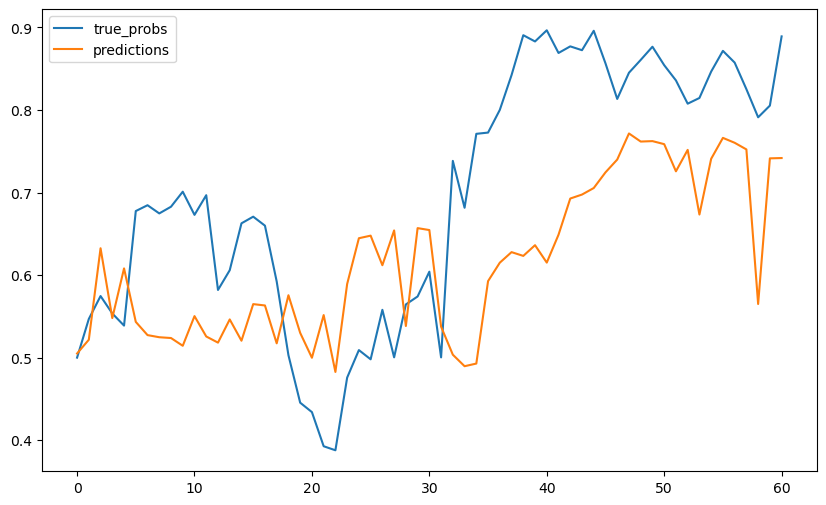

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(test_run_df["steps"],test_run_df["true_probs"], label= "true_probs")
plt.plot(test_run_df["steps"],test_run_df["predictions"], label= "predictions")
plt.legend()
plt.show()

## 6. Integration Test — z_t / Q → RL Environment

Tests that Architecture3 outputs can be fed into `PredictionMarketEnv` via `set_belief_vector` / `set_belief_q`, and that the observation vector grows by the expected number of dimensions.

In [12]:
import copy, yaml
from deep_belief_betting.parameters import Parameters
from deep_belief_betting.prediction_market_env import PredictionMarketEnv
from model.model import Architecture3

# --- load params with belief features enabled ---
with open(PROJECT_ROOT / "configs" / "default.yaml") as f:
    raw = yaml.safe_load(f)

# patch in-memory so we don't have to change the file on disk
raw["belief_features"]["enabled"] = True
raw["belief_features"]["mode"] = "vector"
raw["features"]["include_belief_q"] = True

D_Z = cfg.d_z  # from the belief model config loaded earlier

params_belief = Parameters.from_dict(raw)

# --- build env with belief slots ---
env_b = PredictionMarketEnv(params=params_belief, belief_dim=D_Z)
obs_baseline, _ = env_b.reset(seed=0)

obs_dim_no_belief = sum([
    int(params_belief.features.include_public_probability),
    int(params_belief.features.include_same_day_flow),
    int(params_belief.features.include_time_to_resolution),
    int(params_belief.features.include_position_flag),
    int(params_belief.features.include_position_side),
    int(params_belief.features.include_cash_pnl),
    int(params_belief.features.include_entry_probability),
    int(params_belief.features.include_entry_costs_when_flat) * 2,
    int(params_belief.features.include_unwind_value_when_invested),
    int(params_belief.features.explicit_dead_state),
])

print(f"obs dim without beliefs : {obs_dim_no_belief}")
print(f"obs dim with z_t + Q    : {len(obs_baseline)}  (expected {obs_dim_no_belief + D_Z + 1})")
assert len(obs_baseline) == obs_dim_no_belief + D_Z + 1, "obs dim mismatch!"
print("obs dim check PASSED")

obs dim without beliefs : 11
obs dim with z_t + Q    : 28  (expected 28)
obs dim check PASSED


## 7. Mini PPO Training Run with Belief Model

Runs a full (short) PPO training loop that uses Architecture3 as a live belief encoder. At every env step the belief model consumes the per-env market history, produces z_t and Q, and injects them into the observation via `set_belief_vector` / `set_belief_q`.

In [ ]:
import io, contextlib, json, tempfile
from pathlib import Path

ck_path = PROJECT_ROOT / cfg.checkpoint_path
assert ck_path.exists(), f"Checkpoint not found at {ck_path} — re-run section 4 first."

print(f"belief checkpoint  → {ck_path}")
print(f"belief_dim (d_z)   = {cfg.d_z}")
print(f"world config       → default.yaml  (belief_features.enabled=true, include_belief_q=true)")
print(f"obs grows by         {cfg.d_z} (z_t) + 1 (Q) dims vs no-belief baseline")

belief checkpoint  → /Users/assermaamoun/Documents/GeorgiaTech/GT-Courses/DL-CS7643/FinalProject/deep-belief-betting/runs/belief/test_belief_model.pt
belief_dim (d_z)   = 16
world config       → default.yaml  (belief_features.enabled=true, include_belief_q=true)
obs grows by         16 (z_t) + 1 (Q) dims vs no-belief baseline


In [14]:
from deep_belief_betting.agent_training.training_config import TrainingConfig
from deep_belief_betting.agent_training.train_ppo import train_ppo
from deep_belief_betting.agent_training.device import resolve_device

mini_cfg = TrainingConfig(
    seed=42,
    num_envs=4,
    num_updates=20,
    rollout_steps=64,
    num_minibatches=8,
    device="auto",
    log_dir=str(PROJECT_ROOT / "runs" / "ppo_belief_test"),
    run_name="belief_test",
    save_interval=20,
    log_interval=1,
    world_yaml_base_path=str(PROJECT_ROOT / "configs" / "default.yaml"),
    hidden_dim=64,
    num_layers=2,
    lr=3e-4,
    max_grad_norm=0.5,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    entropy_coef=0.0,
    value_coef=0.5,
    ppo_epochs=4,
    belief_on=True,
    belief_dim=cfg.d_z,
    belief_checkpoint_path=str(ck_path),
    belief_q_on=True,
    use_tensorboard=True,
)

device = resolve_device(mini_cfg.device)
run_dir = train_ppo(mini_cfg, device)
print(f"\nDone. Artifacts: {run_dir}")

TensorBoard: tensorboard --logdir .//Users/assermaamoun/Documents/GeorgiaTech/GT-Courses/DL-CS7643/FinalProject/deep-belief-betting/runs/ppo_belief_test/belief_test_20260428_180237/tb
[belief] loaded Architecture3  d_z=16  path=/Users/assermaamoun/Documents/GeorgiaTech/GT-Courses/DL-CS7643/FinalProject/deep-belief-betting/runs/belief/test_belief_model.pt
{"denominator_for_avg": 32, "entropy_loss": 0.12595, "grad_norm_total": 0.93686, "kl_div": -0.00144, "pnl_avg": 0.0, "policy_loss": -0.00141, "total_loss": 0.00224, "value_loss": 0.00729}
{"denominator_for_avg": 32, "entropy_loss": 0.10032, "grad_norm_total": 0.60865, "kl_div": 0.00161, "pnl_avg": 0.0, "policy_loss": -0.00478, "total_loss": -0.00397, "value_loss": 0.00162}
{"denominator_for_avg": 32, "entropy_loss": 0.06711, "grad_norm_total": 0.41868, "kl_div": -0.001, "pnl_avg": 0.0, "policy_loss": -0.00124, "total_loss": -0.00011, "value_loss": 0.00227}
{"denominator_for_avg": 32, "entropy_loss": 0.10184, "grad_norm_total": 0.58123,

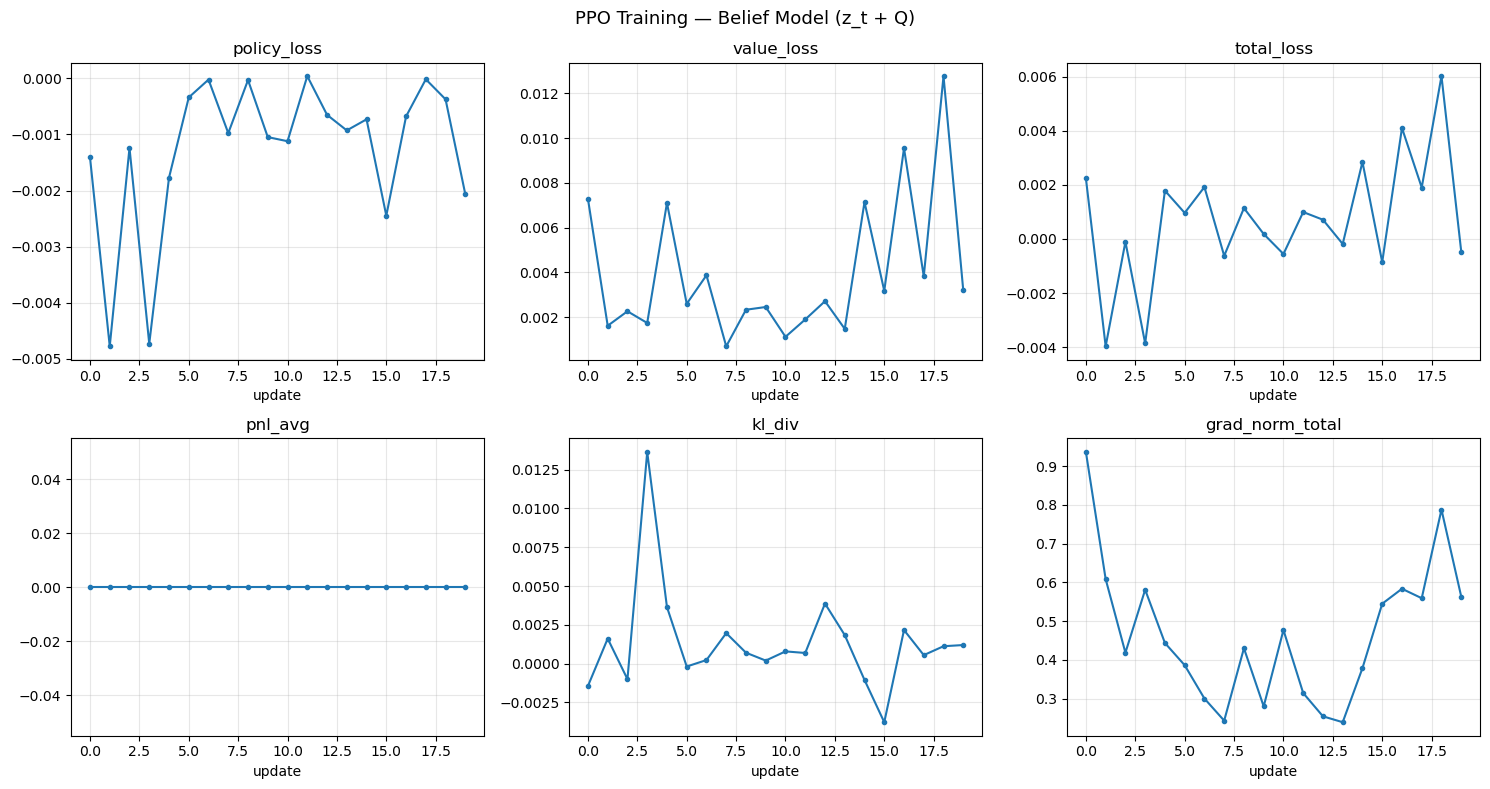

In [15]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(str(run_dir / "tb"))
ea.Reload()

keys = ["metrics/policy_loss", "metrics/value_loss", "metrics/total_loss",
        "metrics/pnl_avg", "metrics/kl_div", "metrics/grad_norm_total"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, key in zip(axes, keys):
    if key in ea.Tags()["scalars"]:
        events = ea.Scalars(key)
        steps  = [e.step for e in events]
        vals   = [e.value for e in events]
        ax.plot(steps, vals, marker="o", markersize=3)
    ax.set_title(key.split("/")[-1])
    ax.set_xlabel("update")
    ax.grid(True, alpha=0.3)

plt.suptitle("PPO Training — Belief Model (z_t + Q)", fontsize=13)
plt.tight_layout()
plt.show()

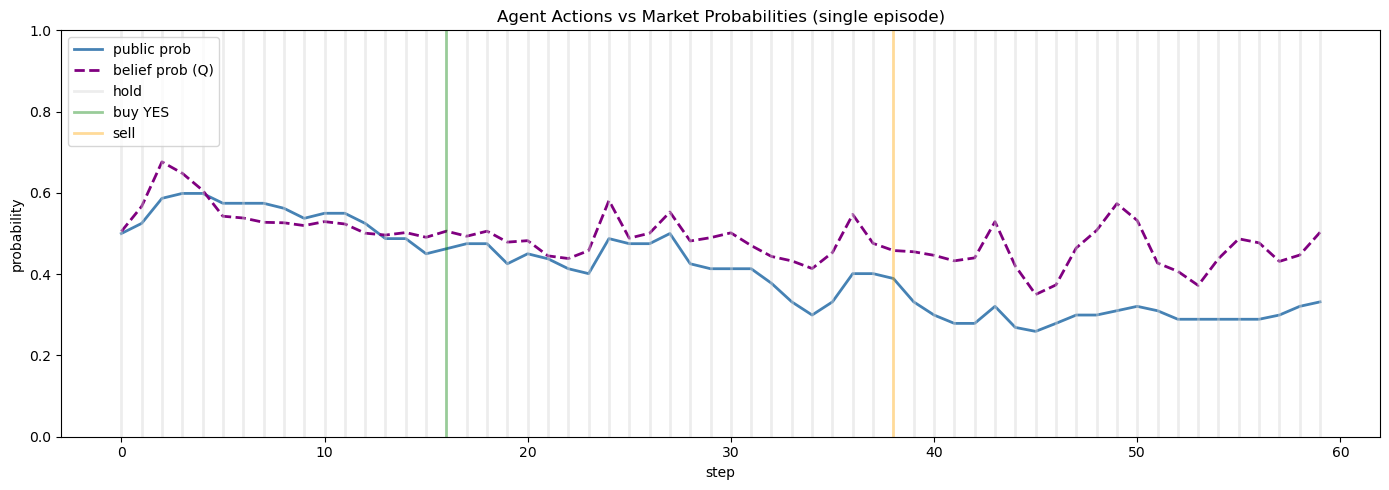

In [16]:
import glob
from torch.distributions import Categorical
from deep_belief_betting.agent_training.policy.mlp_actor_critic import ActorCritic

# load latest PPO checkpoint from the mini run
ckpts = sorted(glob.glob(str(run_dir / "checkpoints" / "*.pt")))
assert ckpts, "no PPO checkpoint found"
ppo_ck = torch.load(ckpts[-1], map_location="cpu", weights_only=False)

# rebuild belief model from the saved checkpoint
belief_ck = torch.load(ck_path, map_location="cpu", weights_only=False)
belief_model_cfg = SimpleNamespace(**belief_ck["cfg"])
belief_model_eval = Architecture3(belief_model_cfg)
belief_model_eval.load_state_dict(belief_ck["model"])
belief_model_eval.eval()

# build a fresh single env and PPO policy
params_eval = Parameters.from_yaml(PROJECT_ROOT / "configs" / "default.yaml")
env_eval = PredictionMarketEnv(params=params_eval, belief_dim=cfg.d_z)
obs, info = env_eval.reset(seed=999)

eval_model = ActorCritic(len(obs), 4, hidden_dim=mini_cfg.hidden_dim,
                         num_layers=mini_cfg.num_layers, device=torch.device("cpu"))
eval_model.load_state_dict(ppo_ck["model"])
eval_model.eval()

# run one episode
pub_probs, belief_probs, actions, step_list = [], [], [], []
seq_buf = []
done = False
t = 0

while not done:
    ms = env_eval.market.get_state()
    seq_buf.append([ms.public_probability, ms.delta_q])
    x = torch.tensor(seq_buf, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        p_t, _, z_t = belief_model_eval(x)
    env_eval.set_belief_vector(z_t[0].cpu().numpy())
    env_eval.set_belief_q(float(p_t[0]))

    pub_probs.append(ms.public_probability)
    belief_probs.append(float(p_t[0]))
    step_list.append(t)

    obs_t = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)
    mask_t = torch.as_tensor(info["action_mask"], dtype=torch.int64).unsqueeze(0)
    with torch.no_grad():
        logits, _ = eval_model(obs_t)
        action = Categorical(logits=logits.masked_fill(mask_t == 0, float("-inf"))).sample().item()

    actions.append(action)
    obs, _, terminated, truncated, info = env_eval.step(action)
    done = terminated or truncated
    t += 1

# plot
ACTION_COLORS = {0: "lightgray", 1: "green", 2: "red", 3: "orange"}
ACTION_LABELS  = {0: "hold", 1: "buy YES", 2: "buy NO", 3: "sell"}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(step_list, pub_probs,    color="steelblue", linewidth=2, label="public prob")
ax.plot(step_list, belief_probs, color="purple",    linewidth=2, linestyle="--", label="belief prob (Q)")
ax.set_ylim(0, 1)
ax.set_ylabel("probability")
ax.set_xlabel("step")

seen_actions = set()
for s, a in zip(step_list, actions):
    label = ACTION_LABELS[a] if a not in seen_actions else None
    ax.axvline(x=s, color=ACTION_COLORS[a], alpha=0.4, linewidth=2, label=label)
    seen_actions.add(a)

ax.legend(loc="upper left")
ax.set_title("Agent Actions vs Market Probabilities (single episode)")
plt.tight_layout()
plt.show()
